# KNNs

This is a notebook to compare the performance of linear probes and knns. With k=1, nearest neighbours is fairly nonlinear, whereas a linear probe should never be able to pick out nonlinear

### Questions:
- Are there differences in performance with KNN and linear probing?
- Is k=1 the most different from linear probes with high performance?

Experiment considerations: are we comparing apples to apples? The fundamental way the two experiments were set up is different (linear probing we train on a training set, evaluate on a test set. KNN we fit the entire dataset then ask about k nearest neighbours and check if the label is right.). We're also not comparing performance on the same thing.

In [1]:
%load_ext autoreload
%autoreload 2

### Imports and loading

In [ ]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import re
from functools import reduce

from project.utils.strs import plms, knn_result_dir, linear_probe_metrics_dir, knn_compiled_results_dir, knn_figures_dir

In [ ]:
# Make dirs if they don't exist already
for directory in [knn_result_dir, linear_probe_metrics_dir, knn_compiled_results_dir, knn_figures_dir]:
    directory.mkdir(parents=True, exist_ok=True)

Reading KNN results

In [3]:
# # knn_dir = Path('/home/mila/s/shawn.whitfield/scratch/results/nearest_neighbor')
# knn_dir = Path('/home/mila/s/shawn.whitfield/scratch/results/nearest_neighbor_splits') # This is the version that's more equivalent to the linear probing
# knn_fig_dir = Path('/home/mila/s/shawn.whitfield/scratch/results/knns/figures')
# knn_fig_dir.mkdir(parents=True, exist_ok=True)

In [4]:

dfs = []
for file in knn_result_dir.iterdir():
    if str(file).endswith('.parquet.gz'):
        # read file
        df = pl.read_parquet(file)
        dfs.append(df)
knn_results = pl.concat(dfs, how='diagonal')
# Add relative depth column
knn_results = knn_results.with_columns(
    pl.col('model_name').map_elements(lambda x: plms[x]['num_hiddens'], return_dtype=pl.Int16).alias('num_hiddens')
).with_columns(
    (pl.col('layer_num') / (pl.col('num_hiddens')-1)).round(2).alias('relative_depth')
) 

Reading linear probe results

In [5]:
# Get all files associated with the target datasets

mean_dfs = []
for dataset in knn_results['dataset'].unique():
    for d_path in linear_probe_metrics_dir.glob(f"*{dataset}*"):
        if ('tiny' not in str(d_path)) and ('medium' not in str(d_path)):
            dataset_dfs = []
            
            # Use d_path here since we used 'd' for the dataframe later
            for f in d_path.iterdir():
                try:
                    # Attempt to read the individual file
                    temp_df = pl.read_parquet(f)
                    dataset_dfs.append(temp_df)
                except Exception as e:
                    # This will catch the "PAR1" error and skip the bad file
                    print(f"Skipping corrupted file {f.name}: {e}")
                    continue 

            if dataset_dfs:
                df = pl.concat(dataset_dfs, how='diagonal_relaxed')
                # Clean columns and append
                clean_df = df.select([c for c in df.columns if ('elementwise' not in c)])
                mean_dfs.append(clean_df)

mean_df = pl.concat(mean_dfs, how='diagonal_relaxed')

# Adjust the dataset nomenclature and extract metadata
mean_df = mean_df.with_columns([
    # 1. Extract '512_cutoff' if present, otherwise default to 'standard' (or null)
    pl.col("dataset")
    .str.extract(r"_(512_cutoff)", 1)
    .fill_null("standard")
    .alias("data_subset"),

    # 2. Extract the split number
    pl.col("dataset")
    .str.extract(r"_split(\d+)$", 1)
    .fill_null("0")
    .alias("split"),

    # 3. Clean the dataset name by removing the split and the cutoff suffixes
    pl.col("dataset")
    .str.replace(r"_512_cutoff", "")  # Remove cutoff
    .str.replace(r"_split\d+$", "")   # Remove split
    .alias("dataset")
]).with_columns(
    pl.col("split").cast(pl.Int64)
)

mean_df = mean_df.filter(
    (pl.col('data_subset') == 'standard'),
    (pl.col('split') == 0))

mean_df = mean_df.unique(subset=['dataset', 'model_name', 'layer_num', 'plm_state', 'plm_embeddings_normalized', 'linear_probe_state', 'control_type', 'fold'])

### Combining the results

In [6]:
# Add experiment column to knn results
knn_results = knn_results.with_columns(
    pl.lit('knn k = ').alias('experiment')
).with_columns(
    pl.concat_str(['experiment', 'k'], separator= ' ').alias('experiment')
)
# Add experiment column to linear probe results
mean_df = mean_df.with_columns(
    pl.lit('linear probing').alias('experiment')
)

# Combine dfs
combined_results = pl.concat([knn_results, mean_df], how='diagonal_relaxed').drop('confusion') # Confusion is a list, interferes later

In [7]:
combined_results.sort(by=['dataset', 'model_name', 'layer_num', 'control_type']).write_parquet(knn_compiled_results_dir / 'compiled_knn_probing_results.parquet.gz')

### Plotting knn vs linear probing

euclidean amplify_120m


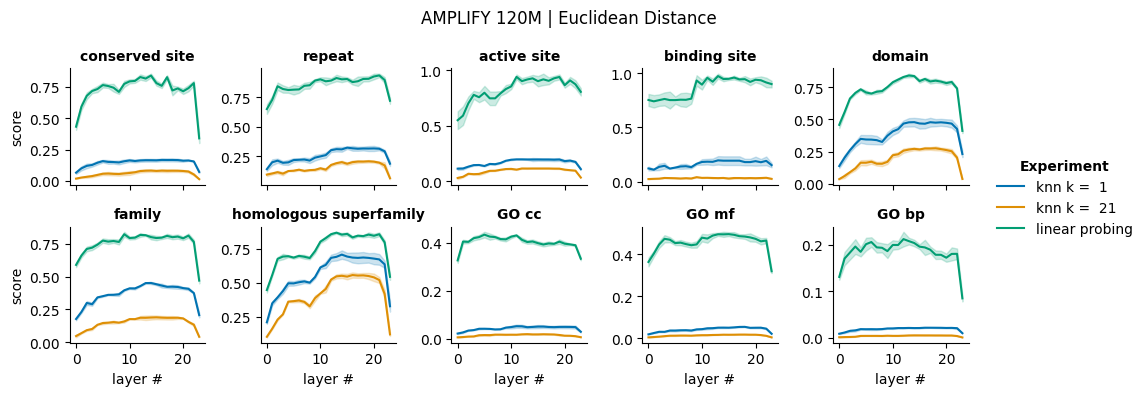

euclidean amplify_350m


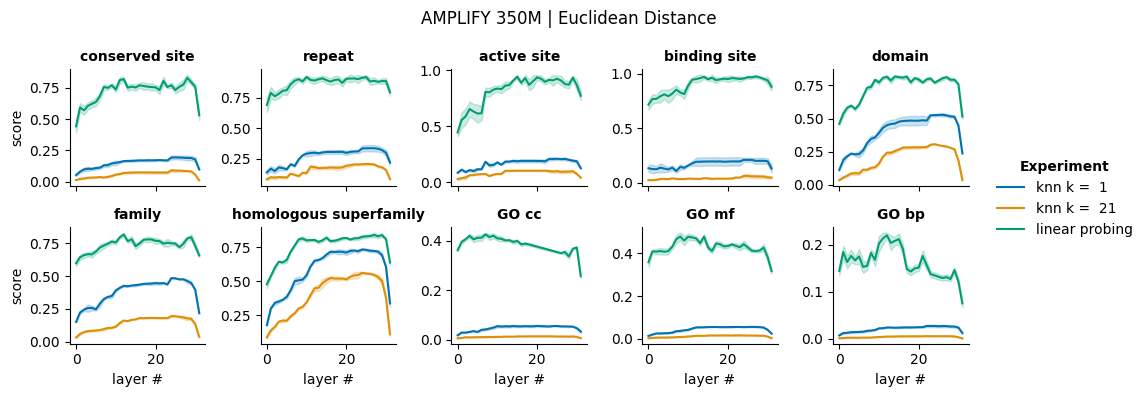

euclidean esm2_150m


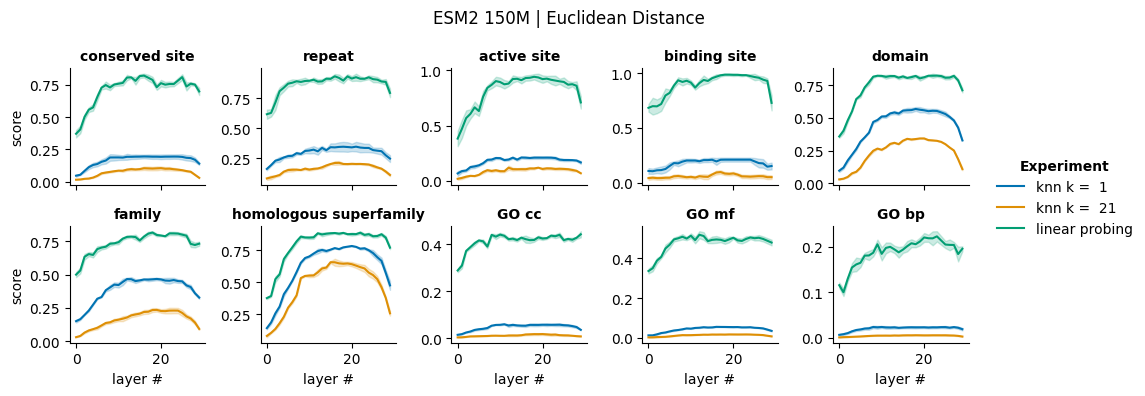

euclidean esm2_650m


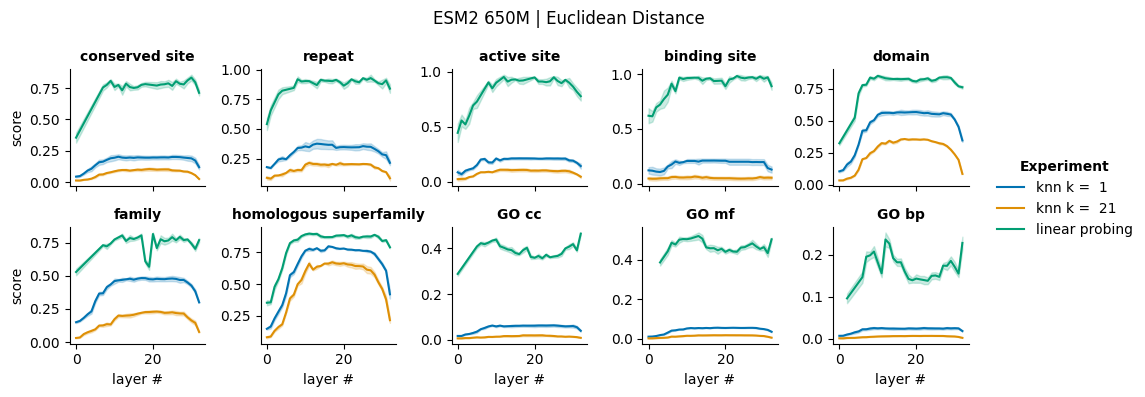

cosine amplify_120m


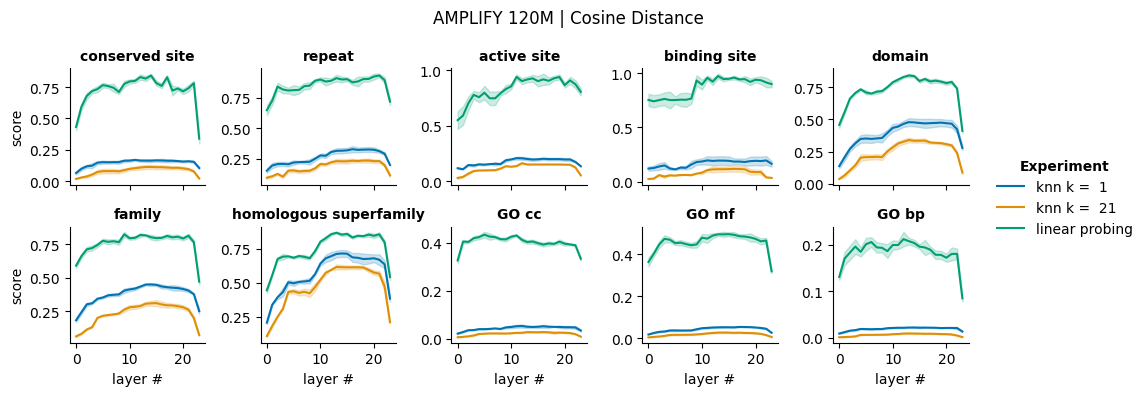

cosine amplify_350m


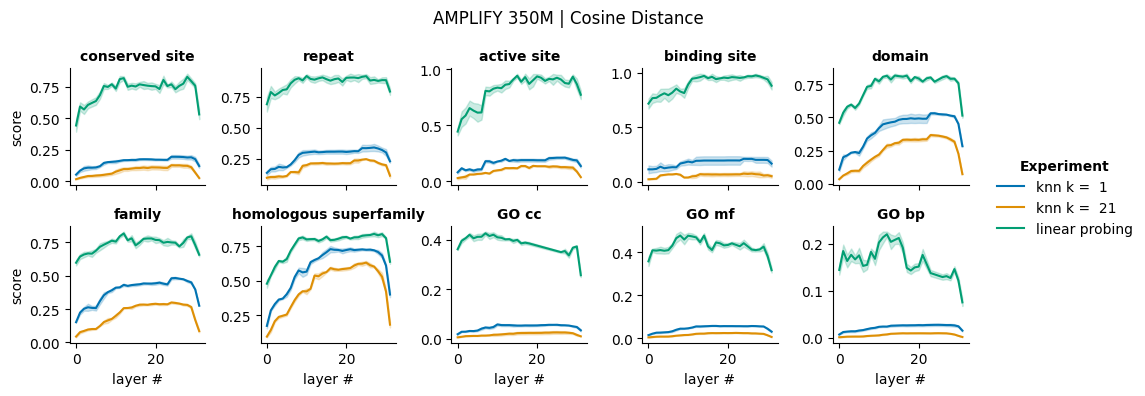

cosine esm2_150m


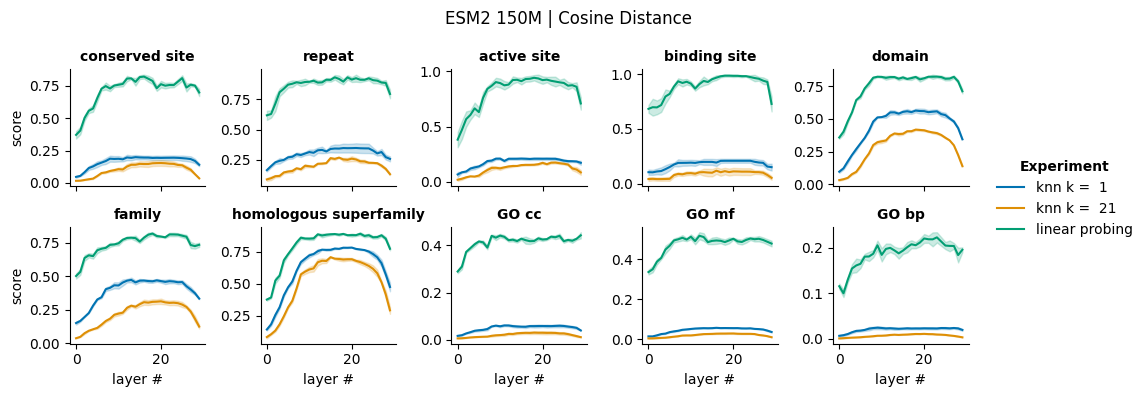

cosine esm2_650m


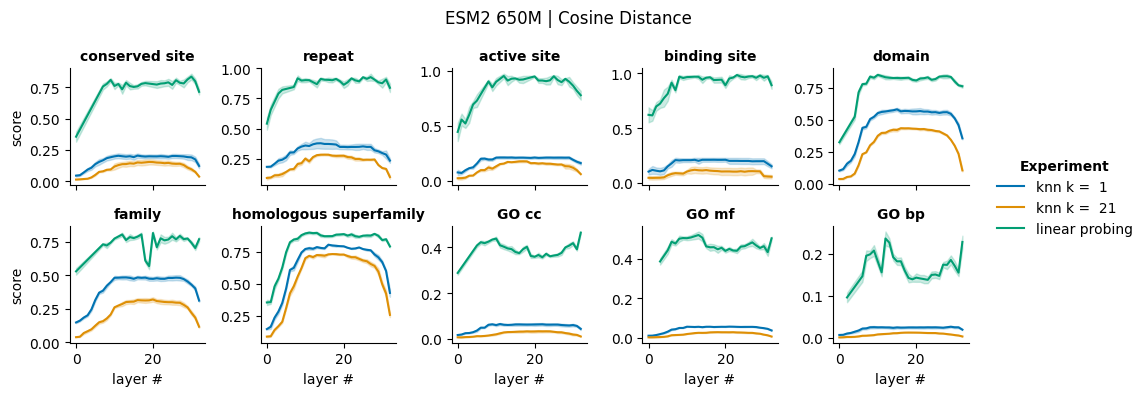

In [10]:
plm_states = ['trained', ] #'un-trained'
probe_states = ['trained', ] # 'un-trained'
show_controls = ['original', 'embeddings'] # 'scrambled', 'mean', 'l2_normalized', 'random_gaussian'
model_order = ['amplify_120m', 'amplify_350m', 'esm2_150m','esm2_650m',] #'esm2_8m', 'esm2_35m', ,   'samplify_120m', 'amplify_350m', 'samplify_350m'
dataset_order = ['interpro_conserved_site', 'interpro_repeat', 'interpro_active_site', 'interpro_binding_site', 
                'interpro_domain', 'interpro_family', 'interpro_homologous_superfamily',
                'GO_cc', 'GO_mf', 'GO_bp']
xaxis_var = 'layer_num'
embed_treatment = 'embeddings'
strategy = 'k'
focus_ks = [1, 21]
distance_metrics = ['euclidean', 'cosine']
weight_strategy = 'distance'
# layer_nums = list(range(0,all_results['num_hiddens'].max() +1, 3))
# relative_depths = [0.0, 0.2,0.4,0.6,1.0]

for distance_metric in distance_metrics:
    for model in model_order:
        print(distance_metric, model)
        all_filters = [
            (pl.col('model_name') == model), # model filter
            (pl.col('dataset').is_in(dataset_order)), # dataset filter
            (pl.col('k').is_in(focus_ks) | pl.col('k').is_null()),
            (pl.col('control_type').is_in(show_controls) | pl.col('control_type').is_null()),
            ((pl.col('distance_metric') == distance_metric) | pl.col('distance_metric').is_null()),
            ((pl.col('weight_strategy') == weight_strategy) | pl.col('weight_strategy').is_null()),
            ((pl.col('plm_embeddings_normalized') == False) | pl.col('plm_embeddings_normalized').is_null()), # normalization filter
            (pl.col('plm_state').is_in(plm_states) | pl.col('plm_state').is_null()), # plm training filter
            (pl.col('linear_probe_state').is_in(probe_states) | pl.col('linear_probe_state').is_null()), # probe training filter
            (pl.col('control_type').is_in(show_controls) | pl.col('control_type').is_null()), # control filter
            (~((pl.col('plm_state') == 'un-trained') & (pl.col('linear_probe_state') == 'un-trained')) | (pl.col('linear_probe_state').is_null() & pl.col('plm_state').is_null())), # untrained filter
        ]

        # Apply filters
        combined_filter = reduce(lambda a, b: a & b, all_filters)
        df_filtered = combined_results.filter(combined_filter)

        # Specify what we want to look at
        xaxis_var = 'layer_num'
        color_by = 'experiment'
        style_by = 'model_name'
        col_by = 'dataset'
        col_wrap_num = 5
        # row_by = 'dataset'

        dataset_regex = r"(uniprot_|interpro_|biomap_)"

        # Choose to look at mcc because that's what we've generally been looking at, it should be a metric that best takes into account class imbalance 
        score_metric = 'matthews_corrcoef' # coverage_error	label_ranking_average_precision_score	label_ranking_loss	f1_score_macro	precision_score_macro	recall_score_macro	jaccard_score_macro

        fig = sns.relplot(data = df_filtered.with_columns(
                pl.col("dataset").str.replace_all(dataset_regex, "") # Adjust dataset names for showing in figure
            ), 
            x= xaxis_var, 
            y = score_metric,
            col = col_by,
            col_wrap = col_wrap_num,
            col_order = [re.sub(dataset_regex, "", i) for i in dataset_order],
            # row = row_by,
            # row_order = dataset_order,
            kind = 'line', 
            markers=True,
            # style=style_by,
            # style_order=model_order,
            errorbar='sd',
            hue = color_by, 
            height = 2,
            palette = 'colorblind',
            facet_kws={'sharey': False},
            )
        fig.set_titles(col_template='{col_name}', row_template='{row_name}')

        residue_tasks = [
        'lipidation', 'topology', 'peptide', 'functional_sites', 
        'phosphorylation', 'secondary_structure', 'ssp_q3', 'ssp_q8', 
        'post_translational_modification'
        ]

        # 1. Strip regex from the category list to match the plot titles
        residue_tasks_cleaned = [re.sub(dataset_regex, "", t) for t in residue_tasks]

        # 2. Iterate through each subplot axis
        for ax in fig.axes.flat:
            title_text = ax.get_title().replace('_', ' ')
            
            # Check if this dataset is a residue-level task
            if title_text in residue_tasks_cleaned:
                # Style for Residue-level: Bold and Blue
                ax.set_title(title_text, 
                # fontweight='bold', 
                fontstyle='italic', 
                color='black', 
                fontsize=10)
            else:
                # Style for Protein-level: Bold and Dark Orange
                ax.set_title(title_text, 
                fontweight='bold', 
                color='black', 
                fontsize=10)

        fig.fig.suptitle(f"{model.upper().replace('_', ' ')} | {distance_metric.title()} Distance")
        
        fig.set_axis_labels("layer #", "score")
        if fig._legend:
            leg = fig._legend
            leg.set_title('Experiment')
            plt.setp(leg.get_title(), weight='bold')

        fig.tight_layout()
        fig.savefig(knn_figures_dir / f"knn_probing_comparison_splits_{model}_{weight_strategy}_{distance_metric}_{score_metric}_vs_{xaxis_var}_hue_{color_by}_grid_{col_by}.png", dpi=300)
        plt.show()

At k=1, we don't get the same performance as a linear probe (the numbers may not be directly comparable because the linear probes are being scored only on a subset of the data, whereas the knns are scored on the whole data). However, as we go up in biological complexity / organization (repeat -> active_site -> domain -> family -> GO terms) the KNN=1 performance gets closer and closer to probe performance. With GO-biological process, it actually achieves better scores (again, caveats on dataset.)